In [1]:
import random, os, pytz, json
from tqdm import tqdm, trange
from datetime import datetime
timezone = pytz.timezone('America/New_York') 
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
def generate(max_depth, depth, max_length, transition):
    if depth < max_depth:
        p = random.random()
        if max_length >= 2:
            if p < transition[0]:
                return ''
            elif p < transition[0] + transition[1]:
                return '(' + generate(max_depth, depth + 1, max_length-2, transition) + ')'
            else:
                return generate(max_depth, depth, max_length//2, transition) + generate(max_depth, depth, max_length//2, transition)
        elif 0 < max_length < 2:
            if p < transition[0]:
                return ''
            else:
                return '(' + generate(max_depth, depth + 1, max_length-2, transition) + ')'
        else:
            return ''
    elif depth == max_depth:
        p = random.random()
        if max_length >= 2:
            if p < transition[0]:
                return ''
            else:
                return generate(max_depth, depth, max_length//2, transition) + generate(max_depth, depth, max_length//2, transition)
        else:
            return ''

In [3]:
def generate_invalid(max_depth, depth, max_length, transition, weights):
    strategy = random.random()
    if strategy < weights[0]: #insert
        s = "e"*max_length
        #while len(s) >= max_length:
        while len(s) >= max_length or len(s) < 2:
            s = generate(max_depth, depth, max_length, transition)
        idx = random.randint(0, len(s)-1)
        if random.random() < 0.5:
            s = s[:idx] + '(' + s[idx:]
        else:
            s = s[:idx] + ')' + s[idx:]
        return s, "insert"
    elif strategy < weights[0] + weights[1]: # remove
        s = ''
        while len(s) < 2:
            s = generate(max_depth, depth, max_length, transition)
        #s = generate(max_depth, depth, max_length, transition)
        idx = random.randint(0, len(s)-1)
        return s[:idx] + s[idx+1:], "remove"
    elif strategy < weights[0] + weights[1] + weights[2]: # swap
        s = ''
        while len(s) < 2:
            s = generate(max_depth, depth, max_length, transition)
        #s = generate(max_depth, depth, max_length, transition)
        idx = random.randint(0, len(s)-1)
        if s[idx] == '(':
            s = s[:idx] + ')' + s[idx+1:]
        else:
            s = s[:idx] + '(' + s[idx+1:]
        return s, "swap"
    else: # (harder) mess up
        s1, s2 = "e"*max_length, "e"*max_length
        #while len(s1) + len(s2) + 2 > max_length:
        while len(s1) + len(s2) + 2 > max_length or len(s1) < 2 or len(s2) < 2:
            s1 = generate(max_depth, depth, max_length, transition)
            s2 = generate(max_depth, depth, max_length, transition)
        idx = random.randint(0, len(s2)-1)
        return s1 + ')' + s2[:idx] + '(' + s2[idx:], "messup"

In [4]:
def double_check(s):
    """
    If it's valid, return the maximum nesting depth.
    If it's not valid, return -1.
    """
    max_depth = 0
    current_depth = 0
    
    for ch in s:
        if ch == '(':
            current_depth += 1
            max_depth = max(max_depth, current_depth)
        elif ch == ')':
            current_depth -= 1
            if current_depth < 0:
                return -1
    if current_depth != 0:
        return -1
    return max_depth

In [5]:
def make_barplot(data, xlabel, ylabel):
    fig= plt.figure(figsize=(6, 3))
    ax = fig.add_subplot(111)
    ax.bar(data.keys(), data.values(), color='lightblue')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines[['right', 'top']].set_visible(False)
    plt.show()

100%|██████████| 55000/55000 [00:00<00:00, 68252.83it/s]


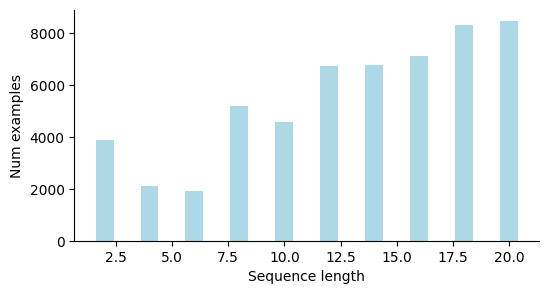

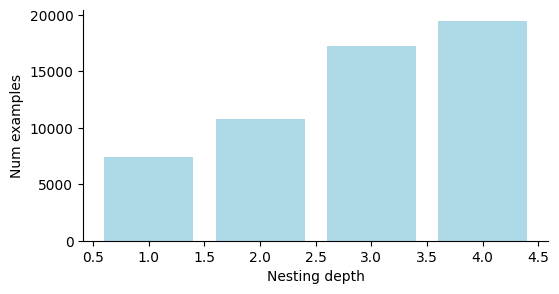

Length distribution: {2: 3881, 4: 2104, 6: 1902, 8: 5187, 10: 4565, 12: 6710, 14: 6778, 16: 7100, 18: 8300, 20: 8473}
Depth distribution: {1: 7451, 2: 10811, 3: 17244, 4: 19494}


In [139]:
### Generate dataset
num_positive, num_negative = 55000, 55000
num_train = 100000
num_val = num_positive + num_negative - num_train
gendate = datetime.now(timezone).strftime("%m%d_%H%M%S")

max_depth = 4
max_length = 20 
min_length = 1
transition = (0.1, 0.4, 0.5)
metadata = {
    "gendate": gendate,
    "max_depth": max_depth,
    "max_length": max_length,
    "min_length": min_length,
    "transition": transition,
    "num_positive": num_positive,
    "num_negative": num_negative,
    "num_train": num_train,
    "num_val": num_val,
}
samples_pos = []
length_dist_pos, depth_dist_pos = Counter(), Counter()

### Generate positives
weights_max_depth_for_valid = [0, 0, 0, 1] 
for i in trange(num_positive):
    max_depth_this_time = random.choices(list(range(1, max_depth+1)), weights=weights_max_depth_for_valid, k=1)[0]
    s = generate(max_depth_this_time, 0, max_length, transition).replace('e', '')
    depth = double_check(s)
    while len(s) < min_length or len(s) > max_length or (not 0 < depth <= max_depth_this_time): # ensure min_length <= length <= max_length
        if depth == -1:
            print(f"False positive: {s}")
        elif depth > max_depth_this_time:
            print(f"Exceed max_depth: {s}")
        s = generate(max_depth_this_time, 0, max_length, transition).replace('e', '')
        depth = double_check(s)
        
    samples_pos.append(json.dumps({
        "length": len(s),
        "depth": depth,
        "sample": s,
        "label": True,
    }))
    length_dist_pos[len(s)] += 1
    depth_dist_pos[depth] += 1
length_dist_pos = dict(sorted(length_dist_pos.items(), key = lambda i: i[0]))
depth_dist_pos = dict(sorted(depth_dist_pos.items(), key = lambda i: i[0]))
make_barplot(length_dist_pos, 'Sequence length', 'Num examples')
make_barplot(depth_dist_pos, 'Nesting depth', 'Num examples')
print(f"Length distribution: {length_dist_pos}")
print(f"Depth distribution: {depth_dist_pos}")

100%|██████████| 55000/55000 [00:02<00:00, 19198.60it/s]


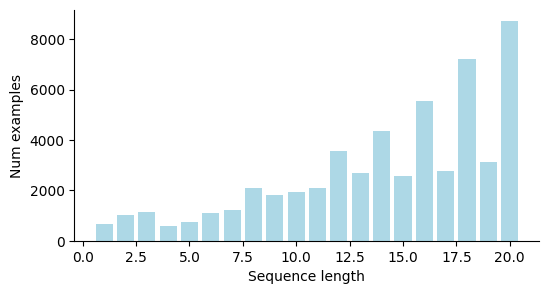

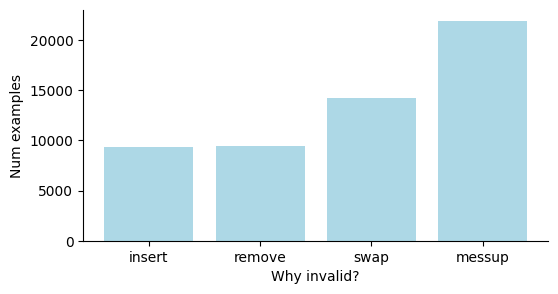

Length distribution: {1: 679, 2: 1032, 3: 1134, 4: 579, 5: 734, 6: 1118, 7: 1214, 8: 2081, 9: 1808, 10: 1928, 11: 2091, 12: 3573, 13: 2679, 14: 4367, 15: 2566, 16: 5557, 17: 2774, 18: 7213, 19: 3134, 20: 8739}
Strategy distribution: {'insert': 9327, 'remove': 9486, 'swap': 14266, 'messup': 21921}


In [140]:
### Generate negatives
transition_for_invalid = (0.1, 0.4, 0.5)
length_dist_neg, strategy_dist_neg = Counter(), Counter()
weights_for_invalid_strategy = [0.15, 0.2, 0.3, 0.35] # insert, remove, swap, messup

samples_neg = []
for i in trange(num_negative):
    s, strategy = generate_invalid(max_depth, 0, max_length, transition_for_invalid, weights_for_invalid_strategy)
    s = s.replace('e', '')
    depth = double_check(s)
    while len(s) < min_length or len(s) > max_length or depth != -1: 
        if depth != -1: print(f"False negative: {s}")
        s, strategy = generate_invalid(max_depth, 0, max_length, transition_for_invalid, weights_for_invalid_strategy)
        s = s.replace('e', '')
        depth = double_check(s)
        
    samples_neg.append(json.dumps({
        "length": len(s),
        "strategy": strategy,
        "sample": s,
        "label": False,
    }))
    length_dist_neg[len(s)] += 1
    strategy_dist_neg[strategy] += 1
length_dist_neg = dict(sorted(length_dist_neg.items(), key = lambda i: i[0]))
strategy_dist_neg = dict(sorted(strategy_dist_neg.items(), key = lambda i: ["insert", "remove", "swap", "messup"].index(i[0])))
make_barplot(length_dist_neg, 'Sequence length', 'Num examples')
make_barplot(strategy_dist_neg, 'Why invalid?', 'Num examples')
print(f"Length distribution: {length_dist_neg}")
print(f"Strategy distribution: {strategy_dist_neg}")

In [144]:
### Save dataset
metadata["weights_max_depth_for_valid"] = weights_max_depth_for_valid
metadata["transition_for_invalid"] = transition_for_invalid
metadata["weights_for_invalid_strategy"] = weights_for_invalid_strategy
metadata["length_dist_pos"] = length_dist_pos
metadata["depth_dist_pos"] = depth_dist_pos
metadata["length_dist_neg"] = length_dist_neg
metadata["strategy_dist_neg"] = strategy_dist_neg

os.makedirs(f"/data/yingshac/model_succ/data/dyck1_{max_depth}/{gendate}", exist_ok=True)
os.makedirs(f"../data/dyck1_{max_depth}/{gendate}", exist_ok=True)

# Save metadata
with open(f"../data/dyck1_{max_depth}/{gendate}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

all_data = samples_pos + samples_neg
random.shuffle(all_data)
train_data, val_data = [], []
j = 0
j_invalid = 0
for datum in all_data:
    x = json.loads(datum)
    if j < num_val and ('depth' not in x) and (j_invalid < num_val//2):
        val_data.append((
            list(x['sample']),
            ['-1']*(len(x['sample'])-1) + [str(int(x['label']))],
        ))
        j += 1
        j_invalid += 1
    elif j < num_val and ('depth' in x) and x['depth'] == max_depth:
        val_data.append((
            list(x['sample']),
            ['-1']*(len(x['sample'])-1) + [str(int(x['label']))],
        ))
        j += 1
    else:
        train_data.append((
            list(x['sample']),
            ['-1']*(len(x['sample'])-1) + [str(int(x['label']))],
        ))
print("#train = ", len(train_data), "#val = ", len(val_data))
# Verify vocab
print(sorted(list(set([w for x in train_data for w in x[0]] + [w for x in train_data for w in x[1]]))))
print(sorted(list(set([w for x in val_data for w in x[0]] + [w for x in val_data for w in x[1]]))))
print("Label distribution: ", "Train: ", Counter(x[1][-1] for x in train_data), "\nVal: ", Counter(x[1][-1] for x in val_data))

#train =  100000 #val =  10000
['(', ')', '-1', '0', '1']
['(', ')', '-1', '0', '1']
Label distribution:  Train:  Counter({'1': 50000, '0': 50000}) 
Val:  Counter({'0': 5000, '1': 5000})


In [145]:
with open(f"/data/yingshac/model_succ/data/dyck1_{max_depth}/{gendate}/train.txt", "w") as f:
    for x in train_data:
        f.write(json.dumps(x) + "\n")
with open(f"../data/dyck1_{max_depth}/{gendate}/val.txt", "w") as f:
    for x in val_data:
        f.write(json.dumps(x) + "\n")
print(gendate)

0327_223322


### Generate same depth, double/triple length testing data

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:00<00:00, 25081.50it/s]


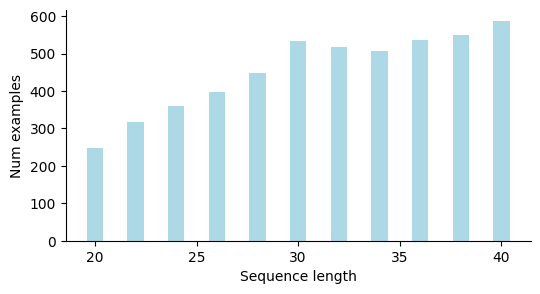

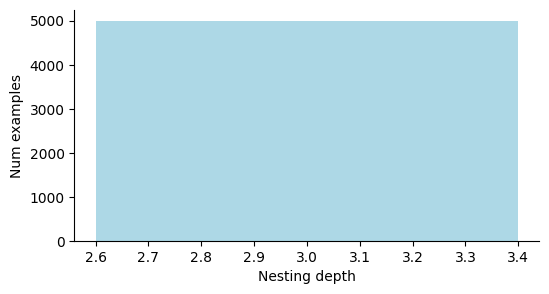

Length distribution: {20: 247, 22: 317, 24: 359, 26: 398, 28: 447, 30: 534, 32: 517, 34: 506, 36: 537, 38: 550, 40: 588}
Depth distribution: {3: 5000}


In [125]:
### Generate dataset
num_positive, num_negative = 5000, 5000
num_train = 0
num_val = num_positive + num_negative - num_train

max_depth = 3
max_length = 40 
min_length = 20
transition = (0.01, 0.4, 0.59)
metadata = {
    "gendate": gendate,
    "max_depth": max_depth,
    "max_length": max_length,
    "min_length": min_length,
    "transition": transition,
    "num_positive": num_positive,
    "num_negative": num_negative,
    "num_train": num_train,
    "num_val": num_val,
}
samples_pos = []
length_dist_pos, depth_dist_pos = Counter(), Counter()

### Generate positives
for i in trange(num_positive):
    s = generate(max_depth, 0, max_length, transition).replace('e', '')
    depth = double_check(s)
    while len(s) < min_length or len(s) > max_length or depth != max_depth: 
        if depth == -1:
            print(f"False positive: {s}")
        elif depth > max_depth:
            print(f"Exceed max_depth: {s}")
        s = generate(max_depth, 0, max_length, transition).replace('e', '')
        depth = double_check(s)
        
    samples_pos.append(json.dumps({
        "length": len(s),
        "depth": depth,
        "sample": s,
        "label": True,
    }))
    length_dist_pos[len(s)] += 1
    depth_dist_pos[depth] += 1
length_dist_pos = dict(sorted(length_dist_pos.items(), key = lambda i: i[0]))
depth_dist_pos = dict(sorted(depth_dist_pos.items(), key = lambda i: i[0]))
make_barplot(length_dist_pos, 'Sequence length', 'Num examples')
make_barplot(depth_dist_pos, 'Nesting depth', 'Num examples')
print(f"Length distribution: {length_dist_pos}")
print(f"Depth distribution: {depth_dist_pos}")

100%|██████████| 5000/5000 [00:00<00:00, 5323.00it/s]


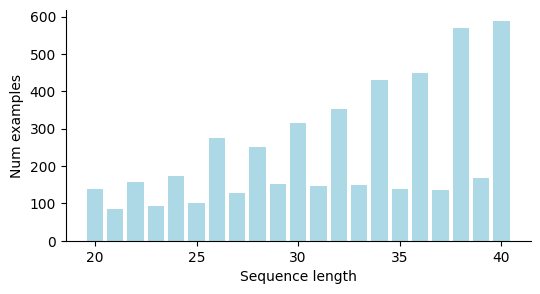

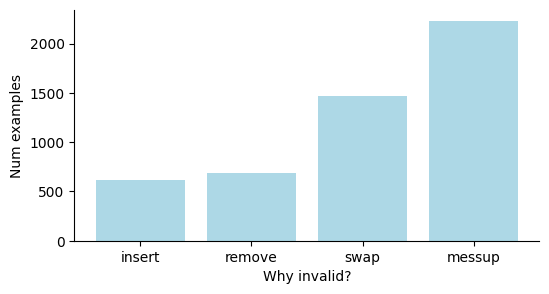

Length distribution: {20: 139, 21: 84, 22: 158, 23: 94, 24: 174, 25: 102, 26: 276, 27: 128, 28: 252, 29: 152, 30: 315, 31: 147, 32: 353, 33: 149, 34: 429, 35: 139, 36: 448, 37: 135, 38: 569, 39: 168, 40: 589}
Strategy distribution: {'insert': 615, 'remove': 683, 'swap': 1470, 'messup': 2232}


In [126]:
### Generate negatives
transition_for_invalid = (0.01, 0.4, 0.59)
length_dist_neg, strategy_dist_neg = Counter(), Counter()
weights_for_invalid_strategy = [0.1, 0.2, 0.4, 0.3] # insert, remove, swap, messup

samples_neg = []
for i in trange(num_negative):
    s, strategy = generate_invalid(max_depth, 0, max_length, transition_for_invalid, weights_for_invalid_strategy)
    s = s.replace('e', '')
    depth = double_check(s)
    while len(s) < min_length or len(s) > max_length or depth != -1: 
        if depth != -1: print(f"False negative: {s}")
        s, strategy = generate_invalid(max_depth, 0, max_length, transition_for_invalid, weights_for_invalid_strategy)
        s = s.replace('e', '')
        depth = double_check(s)
        
    samples_neg.append(json.dumps({
        "length": len(s),
        "strategy": strategy,
        "sample": s,
        "label": False,
    }))
    length_dist_neg[len(s)] += 1
    strategy_dist_neg[strategy] += 1
length_dist_neg = dict(sorted(length_dist_neg.items(), key = lambda i: i[0]))
strategy_dist_neg = dict(sorted(strategy_dist_neg.items(), key = lambda i: ["insert", "remove", "swap", "messup"].index(i[0])))
make_barplot(length_dist_neg, 'Sequence length', 'Num examples')
make_barplot(strategy_dist_neg, 'Why invalid?', 'Num examples')
print(f"Length distribution: {length_dist_neg}")
print(f"Strategy distribution: {strategy_dist_neg}")

In [127]:
### Save dataset
metadata["transition_for_invalid"] = transition_for_invalid
metadata["weights_for_invalid_strategy"] = weights_for_invalid_strategy
metadata["length_dist_pos"] = length_dist_pos
metadata["depth_dist_pos"] = depth_dist_pos
metadata["length_dist_neg"] = length_dist_neg
metadata["strategy_dist_neg"] = strategy_dist_neg

gendate = "0327_221731"
suffix = f"_{min_length}_{max_length}"

# Save metadata
with open(f"../data/dyck1_{max_depth}/{gendate}/metadata{suffix}.json", "w") as f:
    json.dump(metadata, f, indent=4)

all_data = samples_pos + samples_neg
random.shuffle(all_data)
val_data = []
j = 0
for datum in all_data:
    x = json.loads(datum)
    if j < num_val and ('depth' not in x or x['depth'] == max_depth):
        val_data.append((
            list(x['sample']),
            ['-1']*(len(x['sample'])-1) + [str(int(x['label']))],
        ))
        j += 1
    
print(f"#val{suffix} = ", len(val_data))
# Verify vocab
print(sorted(list(set([w for x in val_data for w in x[0]] + [w for x in val_data for w in x[1]]))))
print("Label distribution -- Val: ", Counter(x[1][-1] for x in val_data))

with open(f"../data/dyck1_{max_depth}/{gendate}/val{suffix}.txt", "w") as f:
    for x in val_data:
        f.write(json.dumps(x) + "\n")

#val_20_40 =  10000
['(', ')', '-1', '0', '1']
Label distribution -- Val:  Counter({'1': 5000, '0': 5000})


In [146]:
with open("../data/dyck1_4/0327_214440/val.txt", "r") as f:
    lines = f.readlines()
Counter([l.strip()[-4] for l in lines])

Counter({'0': 5000, '1': 5000})